# Machine Learning Algorithms (Introduction)

This module provides a high-level introduction to Machine Learning, covering key concepts and the landscape of algorithms. This module sets the stage for the following specialized modules.

## Learning Objectives

- Understand what machine learning is
- Distinguish between supervised and unsupervised learning
- Learn the ML pipeline workflow
- Implement a simple classification example
- Implement a simple clustering example


## What is Machine Learning?

Machine Learning involves algorithms that learn patterns from data to make predictions or decisions without being explicitly programmed. 

**Traditional Programming vs Machine Learning:**
- **Traditional**: Write rules → Get answers
- **Machine Learning**: Provide data and answers → Algorithm learns rules

**There are three main types:**

1. **Supervised Learning**: Learning from labeled data (each sample has an associated target/label)
   - **Classification**: Predict categories (spam/not spam, cat/dog/bird)
   - **Regression**: Predict numbers (house price, temperature, age)
   - **Example**: Email spam detection, house price prediction

2. **Unsupervised Learning**: Finding patterns in unlabeled data
   - **Clustering**: Group similar data points
   - **Dimensionality Reduction**: Reduce number of features
   - **Example**: Customer segmentation, anomaly detection

3. **Reinforcement Learning**: Learning through interaction with an environment (not covered in detail here)
   - Agent takes actions, receives rewards/penalties
   - Learns optimal strategy through trial and error
   - **Example**: Game playing (chess, Go), robotics


## Supervised Learning Example: Iris Classification

We'll use the famous Iris dataset to predict flower species from measurements.

**The Iris Dataset:**
- **Features**: Sepal length, sepal width, petal length, petal width (4 measurements)
- **Target**: Flower species (setosa, versicolor, virginica - 3 classes)
- **Samples**: 150 flowers (50 of each species)
- **Task**: Classification (predicting a category)

**Why this dataset?**
- Classic ML benchmark dataset
- Small enough to understand easily
- Well-separated classes (good for learning)
- Real-world application (botanical classification)


In [ ]:
# ============================================
# SUPERVISED LEARNING: Classification Example
# ============================================

# Import necessary libraries and functions
from sklearn.datasets import load_iris  # Load the famous Iris dataset
from sklearn.tree import DecisionTreeClassifier  # Decision tree classification algorithm
from src.models.supervised import split_data, evaluate_classifier  # Our utility functions
import pandas as pd  # For DataFrame operations

# ============================================
# LOADING THE DATASET
# ============================================

# load_iris() loads the Iris flower dataset
# This is a built-in dataset in scikit-learn (no download needed)
iris = load_iris()  # Returns a Bunch object with data, target, feature_names, etc.

# X = Features (inputs): measurements of flowers
# iris.data contains the feature values (150 samples × 4 features)
# We convert to DataFrame for easier manipulation
# columns=iris.feature_names gives meaningful column names
X = pd.DataFrame(iris.data, columns=iris.feature_names)
# X has columns: sepal length, sepal width, petal length, petal width

# y = Target (output): flower species (what we want to predict)
# iris.target contains class labels (0, 1, or 2 for each sample)
# We convert to Series for easier manipulation
y = pd.Series(iris.target)
# 0 = setosa, 1 = versicolor, 2 = virginica

# Display dataset information
print("Iris Dataset:")
print(X.head())  # Show first 5 rows (samples)
print(f"\nTarget names: {iris.target_names}")  # Show species names: ['setosa' 'versicolor' 'virginica']
print(f"Number of samples: {len(X)}")  # Total number of flowers: 150

# ============================================
# TRAIN/TEST SPLIT: Separating Data
# ============================================

# CRITICAL: We must split data BEFORE training
# Why? To test on unseen data (simulates real-world performance)

# split_data() randomly splits data into training (80%) and test (20%) sets
# test_size=0.2 means 20% for testing, 80% for training
# random_state=42 ensures same split every time (reproducibility)
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)
# X_train: 120 samples for training
# X_test: 30 samples for testing
# y_train: labels for training samples
# y_test: labels for test samples (ground truth for evaluation)

# ============================================
# MODEL TRAINING: Learning from Data
# ============================================

# Create a Decision Tree classifier
# Decision trees make predictions by asking yes/no questions about features
# random_state=42 ensures reproducible results
model = DecisionTreeClassifier(random_state=42)

# .fit() trains the model on training data
# The model learns patterns: "If petal length > 2.5, then versicolor"
# This is the "learning" part of machine learning
model.fit(X_train, y_train)  # Train the model

# ============================================
# MODEL EVALUATION: Testing Performance
# ============================================

# Evaluate the model on test data (unseen during training)
# evaluate_classifier() makes predictions and calculates accuracy
results = evaluate_classifier(model, X_test, y_test)

# Accuracy = (correct predictions) / (total predictions)
# 1.000 means 100% accuracy (all 30 test samples predicted correctly)
# This is unusually high - Iris dataset is well-separated
print(f"\nAccuracy: {results['accuracy']:.3f}")  # Output: Accuracy: 1.000


Iris Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target names: ['setosa' 'versicolor' 'virginica']
Number of samples: 150

Accuracy: 1.000


## Unsupervised Learning Example: K-Means Clustering

Now let's see how we can group data without labels using K-Means clustering.

**What is Clustering?**
Clustering groups similar data points together without knowing the groups beforehand. It's like organizing a messy room - you group similar items together.

**K-Means Algorithm:**
1. Choose k cluster centers randomly
2. Assign each point to nearest center
3. Update centers to average of their points
4. Repeat steps 2-3 until convergence

**Key Difference from Classification:**
- **Classification**: We know the categories (supervised)
- **Clustering**: We discover the categories (unsupervised)

**Why use Clustering?**
- Customer segmentation (group similar customers)
- Anomaly detection (find outliers)
- Data exploration (understand data structure)


Silhouette Score: 0.553


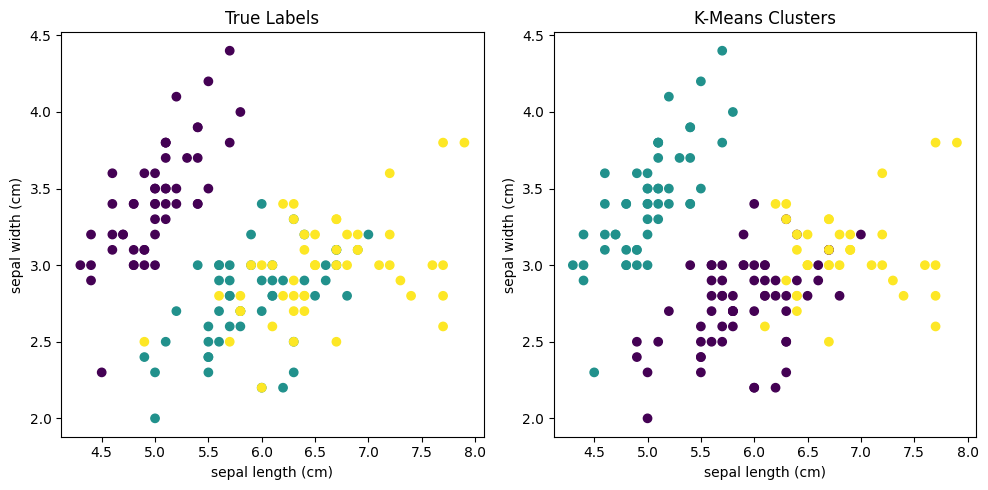

In [ ]:
# ============================================
# UNSUPERVISED LEARNING: Clustering Example
# ============================================

# Import clustering functions and plotting library
from src.models.unsupervised import kmeans_cluster, evaluate_clustering  # Our clustering utilities
import matplotlib.pyplot as plt  # For creating visualizations

# ============================================
# K-MEANS CLUSTERING: Grouping Without Labels
# ============================================

# Use the same Iris data but IGNORE the labels (unsupervised learning)
# X.values converts DataFrame to NumPy array (required by clustering function)
# n_clusters=3 means we want to find 3 groups (we know there are 3 species, but algorithm doesn't!)
# random_state=42 ensures reproducible results

# kmeans_cluster() performs K-Means clustering
# Returns: cluster labels (which cluster each point belongs to) and the fitted model
labels, kmeans = kmeans_cluster(X.values, n_clusters=3, random_state=42)
# labels: Array with cluster assignments (0, 1, or 2 for each sample)
# kmeans: The fitted K-Means model (can be used to predict clusters for new data)

# ============================================
# EVALUATING CLUSTERING QUALITY
# ============================================

# Evaluate how well the clusters separate the data
# Silhouette score measures how similar points are to their own cluster vs other clusters
# Range: -1 (poor clustering) to +1 (excellent clustering)
# Higher is better
silhouette = evaluate_clustering(X.values, labels)  # Calculate silhouette score
print(f"Silhouette Score: {silhouette:.3f}")  # Output: Silhouette Score: 0.553 (moderate quality)

# ============================================
# VISUALIZATION: Comparing True Labels vs Clusters
# ============================================

# Create a figure with 2 subplots side by side
# figsize=(10, 5) sets width=10 inches, height=5 inches
plt.figure(figsize=(10, 5))

# Subplot 1: True labels (what we know from supervised learning)
plt.subplot(1, 2, 1)  # 1 row, 2 columns, position 1 (left)
# X.iloc[:, 0] gets first column (sepal length), X.iloc[:, 1] gets second column (sepal width)
# c=y colors points by true species labels
# cmap='viridis' is a color scheme (green to yellow to purple)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='viridis')
plt.title('True Labels')  # Title for this subplot
plt.xlabel(iris.feature_names[0])  # X-axis label: "sepal length (cm)"
plt.ylabel(iris.feature_names[1])  # Y-axis label: "sepal width (cm)"

# Subplot 2: K-Means clusters (what unsupervised learning discovered)
plt.subplot(1, 2, 2)  # 1 row, 2 columns, position 2 (right)
# Same features, but colored by cluster labels (discovered by algorithm)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='viridis')
plt.title('K-Means Clusters')  # Title for this subplot
plt.xlabel(iris.feature_names[0])  # X-axis label
plt.ylabel(iris.feature_names[1])  # Y-axis label

# Adjust layout to prevent label overlap
plt.tight_layout()
plt.show()  # Display the plot

# Compare the two plots:
# - Left: True species (ground truth)
# - Right: Discovered clusters (algorithm's grouping)
# If they match well, clustering worked! If not, algorithm found different patterns.


## ML Pipeline Summary

The typical ML workflow includes:

1. **Data Preparation**: Loading, cleaning, handling missing values
   - Load data from files or databases
   - Handle missing values (remove or impute)
   - Remove duplicates and outliers
   - Encode categorical variables

2. **Train/Test Split**: Separating data for training and evaluation
   - Split data into training set (80%) and test set (20%)
   - Training set: Used to teach the model
   - Test set: Used to evaluate performance (must be unseen!)

3. **Model Selection**: Choosing an appropriate algorithm
   - Classification: Decision Trees, Random Forest, SVM, etc.
   - Regression: Linear Regression, Polynomial Regression, etc.
   - Clustering: K-Means, DBSCAN, Hierarchical, etc.

4. **Training**: Fitting the model to training data
   - Model learns patterns from training examples
   - This is where "learning" happens

5. **Evaluation**: Testing on unseen data
   - Make predictions on test set
   - Compare predictions to true labels
   - Calculate metrics (accuracy, precision, recall, etc.)

6. **Iteration**: Improving through hyperparameter tuning
   - Adjust algorithm parameters (learning rate, tree depth, etc.)
   - Try different algorithms
   - Improve performance through experimentation

## Summary

In this module, you learned:
- The difference between supervised and unsupervised learning
- How to implement a simple classification model
- How to perform clustering on unlabeled data
- The basic ML pipeline workflow

**Key Takeaways:**
- **Supervised Learning**: Needs labeled data, predicts known outcomes
- **Unsupervised Learning**: Works with unlabeled data, discovers patterns
- **Train/Test Split**: Essential for honest performance evaluation
- **Evaluation Metrics**: Measure how well the model performs

You're now ready to dive deeper into specific ML techniques!
